# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: Após importar as bibliotecas necessárias (pandas e matplotlib.pyplot) e a dataframe, primeiro cria-se a tabela de frequencia, que consiste em realizar a contagem de ocorrências de cada valor na coluna num_caract com value_counts() para obter a frequencia absoluta simples e o mesmo método com o parametro 'normalize=True' para fazer a contagem de frequencias relativas simples. 

Em seguida, para inserir as frequencias na dataframe respeitando os index, usa-se map() informando quais valores serão adicionados. Assim, se o num_carac=4 aparece 2 vezes, a coluna freq (nesse caso, absoluta) referente a esse gene receberá 2 e o mesmo se dá com a freq relativa.

Para gerar o grafico de barras, cria-se uma nova df com as colunas num_carac e freq (fiz graficos separados para ambos os tipos de frequencia) removendo os valores de frequencia duplicados e organizando pelos valores de num_carac. Então, usa-se os módulos de matplotlib para gerar grafico do tipo bar e nomear eixos e titulo.

## 02 – Desenhe o fluxograma da resposta:

## 03 – Escreva o programa em Python:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

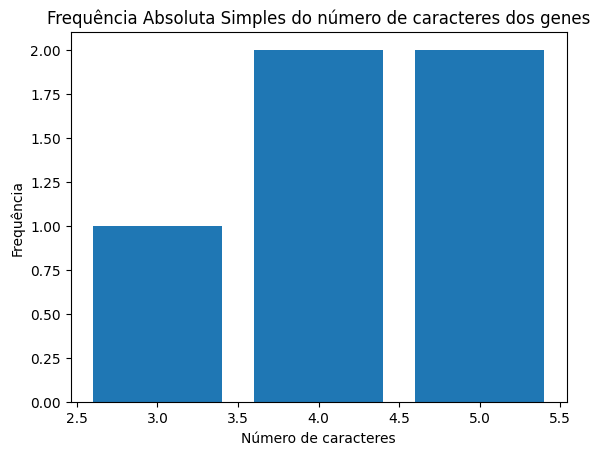

In [39]:
df3_13=pd.read_csv('df_4_8_7lista6.csv', index_col="Unnamed: 0")

freq_abs = df3_13['num_caract'].value_counts()

freq_rel = df3_13['num_caract'].value_counts(normalize=True)

df3_13['Freq Abs Simp'] = df3_13['num_caract'].map(freq_abs)
df3_13['Freq Relat Simp'] = df3_13['num_caract'].map(freq_rel)


df_freq = df3_13[['num_caract', 'Freq Abs Simp']].drop_duplicates().sort_values('num_caract')

plt.bar(df_freq['num_caract'], df_freq['Freq Abs Simp'])

plt.xlabel('Número de caracteres')
plt.ylabel('Frequência')
plt.title('Frequência Absoluta Simples do número de caracteres dos genes')

plt.show()

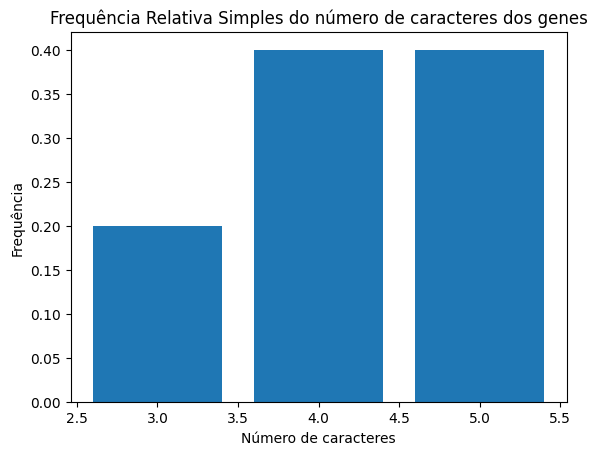

In [40]:
df_freq = df3_13[['num_caract', 'Freq Relat Simp']].drop_duplicates().sort_values('num_caract')

plt.bar(df_freq['num_caract'], df_freq['Freq Relat Simp'])

plt.xlabel('Número de caracteres')
plt.ylabel('Frequência')
plt.title('Frequência Relativa Simples do número de caracteres dos genes')

plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: Após importar as bibliotecas necessárias (pandas e matplotlib.pyplot) e a dataframe, primeiro cria-se a tabela de frequencia já inserindo ela na dataframe original.

Faz-se a contagem de ocorrências de cada valor na coluna num_caract agrupando os dados por essa coluna e devolvendo os valores no mesmo tamanho da df original para nao perder nenhum gene com contagem de caracteres igual. Essa é a freq absoluta simples, a partir da qual obtem-se a freq relativa simples dividindo-a pelo total de valores na dataframe (5). A partir de cada uma dessas frequencias simples obtem-se as respectivas acumuladas com o metodo .cumsum(), que vai somando os valores progressivamente, na ordem em que aparecem.

Para gerar o grafico de barras usando a biblioteca seaborn, deve-se importá-la e com sns.catplot() indicar o tipo de grafico, os dados e os eixos gerar o grafico de barras. Ainda, pode-se criar os "labels" de eixo e titulo do grafico.

## 05 – Desenhe o fluxograma da resposta:

## 06 – Escreva o programa em Python:

C:\Users\bianc\AppData\Local\Temp\ipykernel_17660\4137485604.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


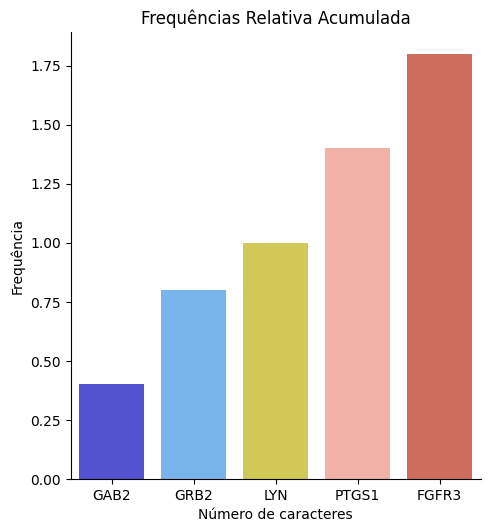

,num_caract,primeiros_2_caract,quant_a,tem_hu,Freq Abs Simp,Freq Rel Simp,Freq Abs Acum,Freq Rel Acum
GAB2,4,GA,1,False,2,0.4,2,0.4
GRB2,4,GR,0,False,2,0.4,4,0.8
LYN,3,LY,0,False,1,0.2,5,1.0
PTGS1,5,PT,0,False,2,0.4,7,1.4
FGFR3,5,FG,0,False,2,0.4,9,1.8


In [19]:
df6_13=pd.read_csv('df_4_8_7lista6.csv', index_col="Unnamed: 0")

df6_13['Freq Abs Simp'] = df6_13.groupby('num_caract')['num_caract'].transform('count')
df6_13['Freq Rel Simp'] = df6_13['Freq Abs Simp'] / len(df6_13)
df6_13['Freq Abs Acum'] = df6_13['Freq Abs Simp'].cumsum()
df6_13['Freq Rel Acum'] = df6_13['Freq Rel Simp'].cumsum()

import seaborn as sns

custom_palette = ["#3C3FE4", '#66B3FF', "#E4D943", "#FFA899","#E0604A"]
sns.catplot(
    kind='bar',
    x=list(df6_13['Freq Rel Acum'].index)[:],
    y='Freq Rel Acum',
    data=df6_13.iloc[:],
    palette=custom_palette
)
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Acumulada")
plt.show()

df6_13

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [25]:
df7_13 = df6_13.drop(columns=['num_caract','primeiros_2_caract', 'quant_a', 'tem_hu'])

df7_13.loc["Total", ['Freq Abs Simp', "Freq Rel Simp"]] = df7_13.sum()
df7_13['Amostra']= 'amostra 1'
df7_13


,Freq Abs Simp,Freq Rel Simp,Freq Abs Acum,Freq Rel Acum,Amostra
GAB2,2.0,0.4,2.0,0.4,amostra 1
GRB2,2.0,0.4,4.0,0.8,amostra 1
LYN,1.0,0.2,5.0,1.0,amostra 1
PTGS1,2.0,0.4,7.0,1.4,amostra 1
FGFR3,2.0,0.4,9.0,1.8,amostra 1
Total,9.0,1.8,NaN,NaN,amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [ ]:
ar8=np.random.randint(1,10,5)

## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.